# Tester_branch에서 성능 확인 진행

In [1]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

df = pd.DataFrame(data=wine.data, columns= wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

# DT 모델링 성능

Best Hyper-parameter {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score 0.9224137931034484


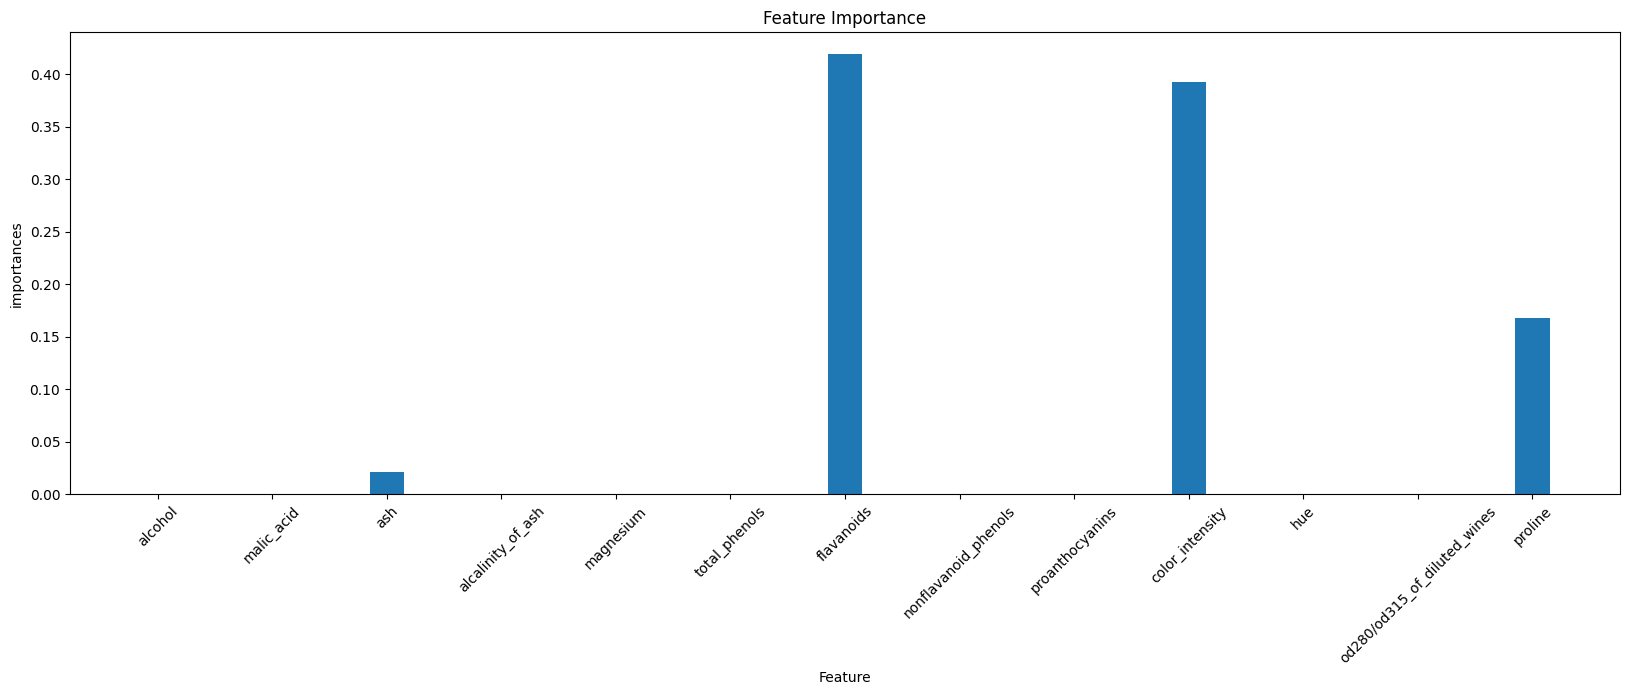

In [2]:
from sklearn.tree import DecisionTreeClassifier

# Admin에서 수정 진행

param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : [2, 3, 4, 5], # Admin에서 수정
    "min_samples_split": [2, 5, 10], # Admin에서 수정
    "min_samples_leaf": [1, 2, 4]
}

clf_grid = DecisionTreeClassifier( random_state= 42 )

grid_search = GridSearchCV(clf_grid, param_grid, cv = 5,  scoring='accuracy')

grid_search.fit(X_train, y_train) # HyperParameter를 찾고, 이걸 가지고 fitting이 모두 수행

print("Best Hyper-parameter", grid_search.best_params_)
print("Best Score", grid_search.best_score_)

clf_best_model = grid_search.best_estimator_

importances = clf_best_model.feature_importances_ # Feature Importance를 계산

plt.figure(figsize = (20,6)) # Best model의 Feature Importance를  시각화

plt.bar(range(len(importances)), importances, width=0.3) # 막대 그래프 생성
plt.xlabel('Feature')
plt.ylabel('importances')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation = 45)
plt.show()

# XGB 모델링 성능

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9576354679802955


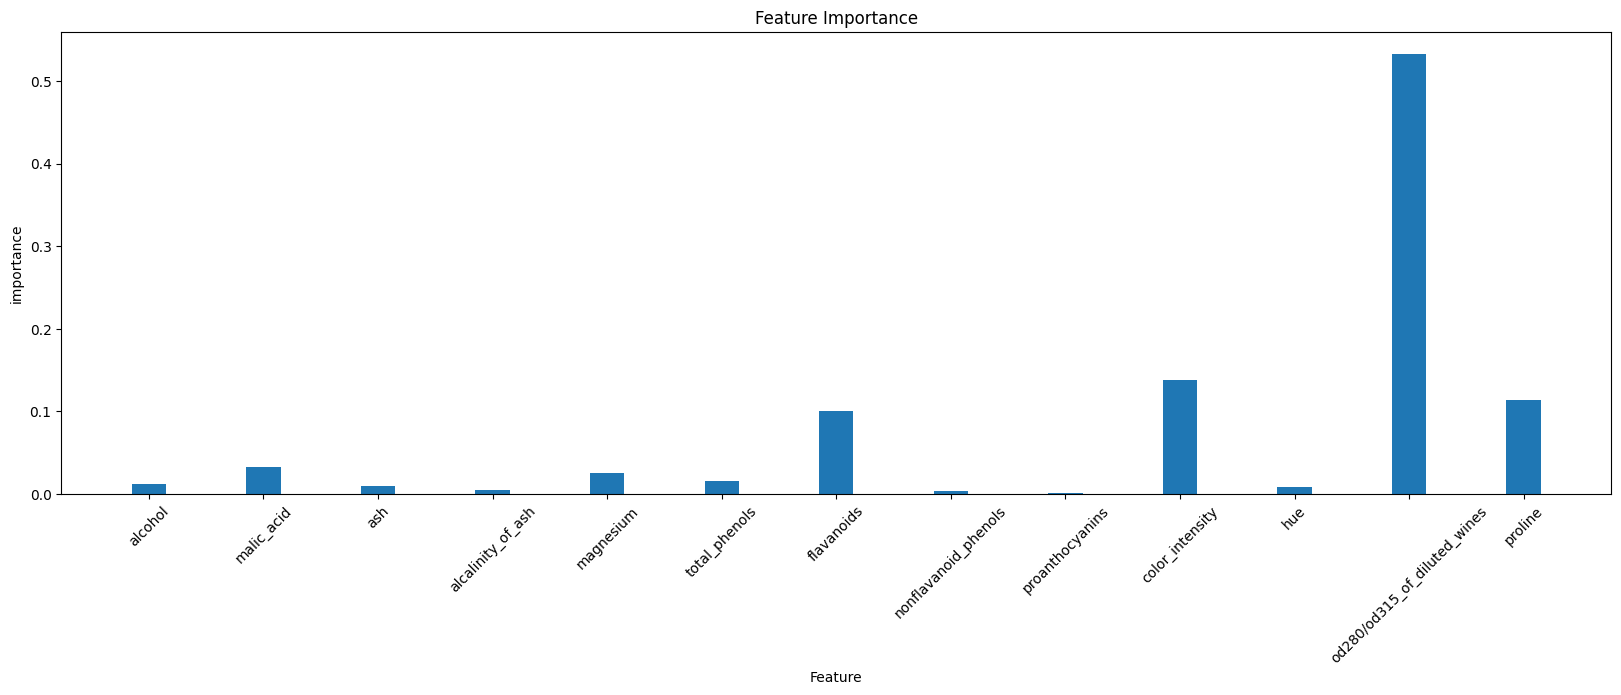

In [4]:
from xgboost import XGBClassifier # Xgboost

xgb_model = XGBClassifier(random_state=42)

params = {
    "max_depth" : [3, 5, 7, 9, 15],
    "learning_rate" : [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200, 300]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=params, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy:" , grid_search.best_score_)

xgb_best_model = grid_search.best_estimator_

importances = xgb_best_model.feature_importances_

plt.figure(figsize= (20,6))

plt.bar(range(len(importances)), importances, width= 0.3)
plt.xlabel('Feature')
plt.ylabel('importance')
plt.title('Feature Importance')
plt.xticks(range(len(importances)), X.columns, rotation =45)
plt.show()

# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



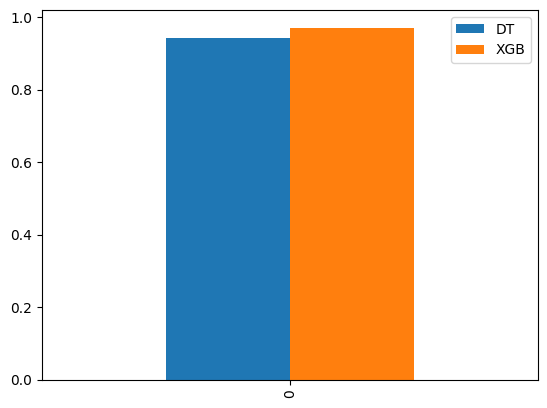

In [5]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_DT_grid = clf_best_model.predict(X_test)
accuracy_DT_grid = accuracy_score(y_test, y_pred_DT_grid)
print('='*20, 'DT 성능 확인', '='*20)
print('DT accuracy :', accuracy_DT_grid)
print(classification_report(y_test, y_pred_DT_grid))


y_pred_grid_XGB = xgb_best_model.predict(X_test) #테스트 데이터에 대한 예측
accuracy_XGB_grid = accuracy_score(y_test, y_pred_grid_XGB)
print('='*20, 'XGB 성능 확인', '='*20)
print('XGB accuracy :', accuracy_XGB_grid)
print(classification_report(y_test, y_pred_grid_XGB) )

tmp_df = pd.DataFrame({'DT' : [accuracy_DT_grid], 'XGB' : [accuracy_XGB_grid]})
tmp_df.plot(kind='bar')
plt.show()